#Preambolo

In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
import uncertainties.umath as unm
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 907.6 kB/s eta 0:00:00


In [ ]:
import os
import sys
import shutil

%cd /content/
if os.path.exists('/content/Esperienze-in-laboratorio'):
    shutil.rmtree('/content/Esperienze-in-laboratorio')

!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git

percorso_libreria = '/content/Esperienze-in-laboratorio/Libreria_python'
if percorso_libreria not in sys.path:
    sys.path.insert(0, percorso_libreria)

try:
    from analisi_dati import *
    print("✅ Tutto pronto! Librerie installate e modulo importato.")
except Exception as e:
    print(f"❌ Errore durante l'import: {e}")

%cd Esperienze-in-laboratorio

/content
Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1092, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 1092 (delta 107), reused 125 (delta 75), pack-reused 932 (from 2)
Receiving objects: 100% (1092/1092), 18.40 MiB | 26.31 MiB/s, done.
Resolving deltas: 100% (573/573), done.
✅ Tutto pronto! Librerie installate e modulo importato.
/content/Esperienze-in-laboratorio


#Pull

In [ ]:
!git pull

Already up to date.


#Raccolta Periodi

In [ ]:
df=pd.read_excel('Kater.xlsx', sheet_name=0)
df=df.fillna('')
df

,D m.e. [m],D m.i. [m],T1 [s],T2 [s]
0,0.12,0.080,1.9995,1.9544
1,,0.100,1.9843,1.9044
2,,0.130,1.9690,1.8761
3,,0.163,1.9644,1.8714
4,,0.190,1.9528,1.8235
5,,0.220,1.9462,1.8037
6,,0.245,1.9361,1.7600
7,,0.270,1.9354,1.7618
8,,0.305,1.9210,1.7654
9,,0.337,1.9114,1.7536


--- Equazioni delle Parabole Interpolanti ---
Parabola T1: T1(x) = 0.5824*x^2 + (-0.6091)*x + 2.0474
Parabola T2: T2(x) = 1.1252*x^2 + (-1.0014)*x + 1.9826


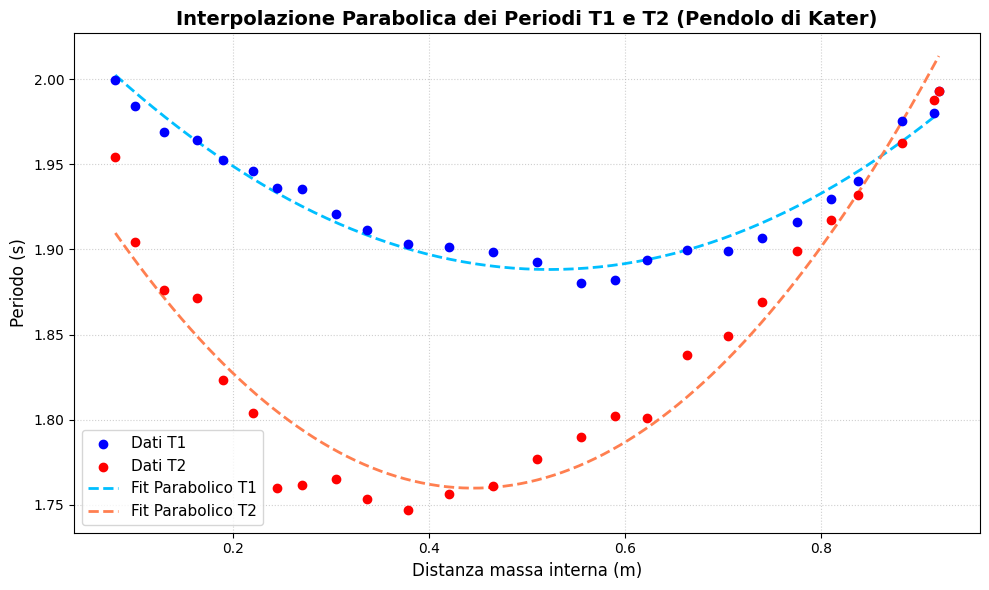

In [ ]:
x = np.array(df.iloc[0:26, 1])

t1 = np.array(df.iloc[0:26, 2])

t2 = np.array(df.iloc[0:26, 3])

p1_coefficients = np.polyfit(x, t1, 2)
p2_coefficients = np.polyfit(x, t2, 2)

fit_t1 = np.poly1d(p1_coefficients)
fit_t2 = np.poly1d(p2_coefficients)

print("="*70)
print("--- Equazioni delle Parabole Interpolanti ---")
print(f"Parabola T1: T1(x) = {p1_coefficients[0]:.4f}*x^2 + ({p1_coefficients[1]:.4f})*x + {p1_coefficients[2]:.4f}")
print(f"Parabola T2: T2(x) = {p2_coefficients[0]:.4f}*x^2 + ({p2_coefficients[1]:.4f})*x + {p2_coefficients[2]:.4f}")
print("="*70)

x_smooth = np.linspace(min(x), max(x), 200)

plt.figure(figsize=(10, 6))

plt.scatter(x, t1, color='blue', label='Dati T1', zorder=5)
plt.scatter(x, t2, color='red', label='Dati T2', zorder=5)

plt.plot(x_smooth, fit_t1(x_smooth), color='deepskyblue', linestyle='--', linewidth=2, label='Fit Parabolico T1')
plt.plot(x_smooth, fit_t2(x_smooth), color='coral', linestyle='--', linewidth=2, label='Fit Parabolico T2')

plt.title('Interpolazione Parabolica dei Periodi T1 e T2 (Pendolo di Kater)', fontsize=14, fontweight='bold')
plt.xlabel('Distanza massa interna (m)', fontsize=12)
plt.ylabel('Periodo (s)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Pendolo di Kater

In [ ]:
df3=pd.read_excel('Kater.xlsx', sheet_name=1)
df3=df3.fillna('')
df3

,Distanza m. interna,"0,915 m",Unnamed: 2,Unnamed: 3,"0,920 m",Unnamed: 5
0,,T1 [s],T2 [s],,T1 [s],T2 [s]
1,,1.9907,1.9875,,1.9911,1.9867
2,,1.9911,1.9873,,1.9863,1.9924
3,,1.9909,1.9894,,1.991,1.9919
4,,1.9919,1.989,,1.9857,1.9926
5,,1.9909,1.9882,,1.9906,1.9904
6,,1.9907,1.9882,,1.9926,1.9905
7,,1.9913,1.988,,1.9929,1.9908
8,,1.9905,1.9887,,1.9906,1.9937
9,,1.9906,1.9879,,1.982,1.99


In [ ]:
# T1 periodo del coltello 1, T2 è quello del coltello 2, ossia quello dal cui lato esterno è posta la seconda massa
# a è il "punto" prima dell'intersezione dei periodi, b quello dopo

d_T1a=df3.iloc[11, 1]
d_T2a=df3.iloc[11, 2]
d_T1b=df3.iloc[11, 4]
d_T2b=df3.iloc[11, 5]

d_sT1a=df3.iloc[13, 1]
d_sT2a=df3.iloc[13, 2]
d_sT1b=df3.iloc[13, 4]
d_sT2b=df3.iloc[13, 5]

T1a=ufloat(d_T1a, d_sT1a)
T2a=ufloat(d_T2a, d_sT2a)
T1b=ufloat(d_T1b, d_sT1b)
T2b=ufloat(d_T2b, d_sT2b)

h=ufloat(1.005, 0.005)
c_o=ufloat(0.090, 0.005)
theta=unm.atan(c_o/h)

print("="*70)
T_star=(T2a*T1b-T1a*T2b)/(T1b-T2b-T1a+T2a)
print(f"Il valore di T* è: {T_star:.4P}")

g_exp = (4*np.pi**(2)*0.994)/(T_star**2)
print(f"Il valore di g è: {g_exp:.4P}")

g_corr = g_exp*(1+theta**(2)/16)**2
print(f"Il valore di g_corr è: {g_corr:.4P}")
print("="*70)

Il valore di T* è: 1.990±0.001
Il valore di g è: 9.911±0.006
Il valore di g_corr è: 9.921±0.006


# Caduta Libera

In [ ]:
df2=pd.read_excel('Kater.xlsx', sheet_name=2)
df2=df2.fillna('')
df2

,Unnamed: 0,Distanza [m],Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,,0.15,0.2,0.25,0.3,0.35,0.4,0.45
1,,Tempi [s],,,,,,
2,,0.1433,0.1698,0.1934,0.2146,0.2342,0.2528,0.2713
3,,0.1434,0.1716,0.1932,0.215,0.2344,0.253,0.2719
4,,0.1433,0.171,0.1933,0.2149,0.2343,0.2537,0.2721
5,,0.1431,0.1703,0.1933,0.2148,0.2342,0.2532,0.2708
6,,0.1432,0.1706,0.1933,0.2152,0.2344,0.2536,0.2718
7,,0.1433,0.1711,0.1936,0.2147,0.2345,0.253,0.2686
8,,0.1431,0.17,0.1936,0.2148,0.2343,0.2534,0.2683
9,M,0.143243,0.170629,0.193386,0.214857,0.234329,0.253243,0.270686


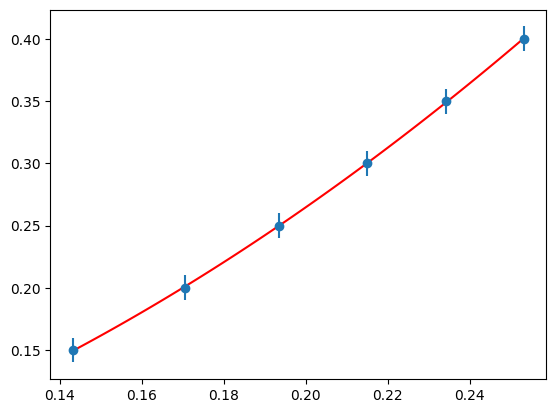

Parametri ottimizzati: a=-0.0050, b=0.3964, c=4.7584
Il risultato del test del χ² è:
  χ²               = 0.028762416
  Gradi di libertà = 3
  χ² ridotto       = 0.0095874719
  Il p-value associato è: 0.99871379
Il valore di g è: 9.517±0.262
Test di compatibilità tra g_exp e g0: |t| = 1.5060565


In [ ]:
#fit parabola con tre parametri

def parabola(x, a, b, c):
  return a + b*x + c*x**2

y = unp.uarray(df2.iloc[0, 1:7], np.full(len(df2.iloc[0, 1:7]), 0.01))
x = unp.uarray(df2.iloc[9, 1:7], df2.iloc[10, 1:7])

popt, pcov = sp.optimize.curve_fit(parabola, unp.nominal_values(x), unp.nominal_values(y), sigma=unp.std_devs(y), p0=[1, 1, 1])

x_plot = np.linspace(min(unp.nominal_values(x)), max(unp.nominal_values(x)), 100)
y_plot = parabola(x_plot, *popt)

plt.errorbar(unp.nominal_values(x), unp.nominal_values(y), yerr=unp.std_devs(y), fmt='o', label='Dati')
plt.plot(x_plot, y_plot, label='Fit Parabolico', color='red')
plt.show()

print("="*70)

print(f"Parametri ottimizzati: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}")

print("="*70)
chi_quadro(unp.nominal_values(y), popt[0] + popt[1]*x + popt[2]*x**2, unp.std_devs(y), n_parametri=3);
s_g0 = 2*np.sqrt(pcov[1, 1])
g0 = ufloat(popt[2]*2, s_g0)

print("="*70)
print(f"Il valore di g è: {g0:.4P}")
t_test(g_exp, g0, nome1="g_exp", nome2="g0");
print("="*70)

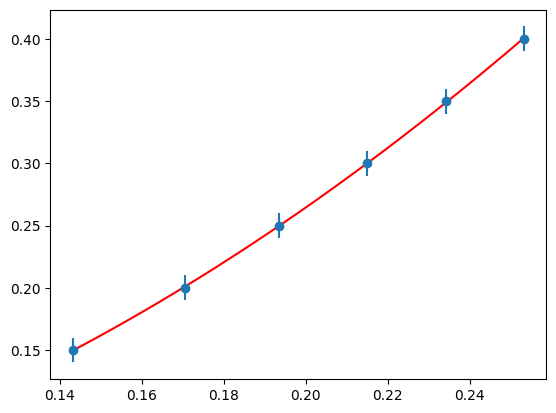

Parametri ottimizzati: b=0.3454, c=4.8852
Il risultato del test del χ² è:
  χ²               = 0.030230141
  Gradi di libertà = 4
  χ² ridotto       = 0.0075575352
  Il p-value associato è: 0.99988691
Il valore di g è: 9.770±0.101
Test di compatibilità tra g_exp e g1: |t| = 1.3904156
Test di compatibilità tra g_teo e g1: |t| = 0.39126192


In [ ]:
#fit parabola con due parametri (assumendo y0 = 0)

def parabola_(x, b, c):
  return b*x + c*x**2

popt, pcov = sp.optimize.curve_fit(parabola_, unp.nominal_values(x), unp.nominal_values(y), sigma=unp.std_devs(y), p0=[1, 1])

x_plot = np.linspace(min(unp.nominal_values(x)), max(unp.nominal_values(x)), 100)
y_plot = parabola_(x_plot, *popt)

plt.errorbar(unp.nominal_values(x), unp.nominal_values(y), yerr=unp.std_devs(y), fmt='o', label='Dati')
plt.plot(x_plot, y_plot, label='Fit Parabolico', color='red')
plt.show()

print("="*70)

print(f"Parametri ottimizzati: b={popt[0]:.4f}, c={popt[1]:.4f}")

print("="*70)
chi_quadro(unp.nominal_values(y), popt[0]*x + popt[1]*x**2, unp.std_devs(y), n_parametri=2);
s_g1 = 2*np.sqrt(pcov[1, 1])
g1 = ufloat(popt[1]*2, s_g1)

print("="*70)
print(f"Il valore di g è: {g1:.4P}")
t_test(g_exp, g1, nome1="g_exp", nome2="g1");
t_test(9.81, g1, nome1="g_teo", nome2="g1");
print("="*70)

In [ ]:
chi_quadro(unp.nominal_values(y), popt[0]*x + popt[1]*x**2, unp.std_devs(y), n_parametri=2);
s_g1 = 2*np.sqrt(pcov[1, 1])
g1 = ufloat(popt[1]*2, s_g1)

print("="*70)
print(f"Il valore di g è: {g1:.4P}")
t_test(g_exp, g1, nome1="g_exp", nome2="g1");
t_test(9.81, g1, nome1="g_teo", nome2="g1");
print("="*70)

Il risultato del test del χ² è:
  χ²               = 0.030230141
  Gradi di libertà = 4
  χ² ridotto       = 0.0075575352
  Il p-value associato è: 0.99988691
------------------------------------------------------
Il valore di g è: 9.770±0.101
Test di compatibilità tra g_exp e g1: |t| = 1.3904156
Test di compatibilità tra g_teo e g1: |t| = 0.39126192
------------------------------------------------------
